<a href="https://colab.research.google.com/github/pxu/Generative_Deep_Learning_2nd_Edition/blob/main/ProGAN_Assignment8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ProGAN – Progressive Growing GAN (Colab Notebook)

This notebook trains a simplified ProGAN to generate facial images.

# **Imports and Device**

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torchvision.utils import save_image
from torch.utils.data import DataLoader
import os
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

Device: cuda


# **Dataset Loader (≤10,000 Images)**

In [17]:
from torchvision.datasets import CelebA
from torch.utils.data import Subset

def get_dataloader(image_size, batch_size):
    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])

    # Download CelebA automatically
    dataset = CelebA(
        root="/content/data",
        split="train",
        download=True,
        transform=transform
    )

    # Restrict to first 10,000 images
    dataset = Subset(dataset, range(10000))

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

# **Core Layers**

**Pixel Normalization**

In [18]:
class PixelNorm(nn.Module):
    def forward(self, x):
        return x / torch.sqrt(torch.mean(x**2, dim=1, keepdim=True) + 1e-8)

**Convolution Block**

In [19]:
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, 1, 1),
            nn.LeakyReLU(0.2),
            PixelNorm(),
            nn.Conv2d(out_c, out_c, 3, 1, 1),
            nn.LeakyReLU(0.2),
            PixelNorm()
        )
    def forward(self, x):
        return self.block(x)

# **Generator**

In [20]:
class Generator(nn.Module):
    def __init__(self, z_dim=256):
        super().__init__()

        # Initial block: latent vector → 4x4 feature map
        self.initial = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 512, kernel_size=4, stride=1, padding=0),
            nn.LeakyReLU(0.2),
            PixelNorm()
        )

        # Progressive convolution blocks
        # Each block is used after up-sampling
        self.blocks = nn.ModuleList([
            ConvBlock(512, 256),  # 8x8
            ConvBlock(256, 128),  # 16x16
            ConvBlock(128, 64),   # 32x32
        ])

        # Convert feature maps to RGB at each resolution
        self.to_rgb = nn.ModuleList([
            nn.Conv2d(512, 3, kernel_size=1),
            nn.Conv2d(256, 3, kernel_size=1),
            nn.Conv2d(128, 3, kernel_size=1),
            nn.Conv2d(64, 3, kernel_size=1),
        ])

    def forward(self, z, step):
        """
        z: latent noise vector (B, z_dim, 1, 1)
        step: current progressive step
              0 -> 4x4
              1 -> 8x8
              2 -> 16x16
              3 -> 32x32
        """

        # Initial 4x4 feature map
        x = self.initial(z)

        # If only 4x4 resolution
        if step == 0:
            return torch.tanh(self.to_rgb[0](x))

        # Progressive growing
        for i in range(step):
            # Nearest-neighbor up-sampling
            x = F.interpolate(x, scale_factor=2, mode="nearest")
            x = self.blocks[i](x)

        # Convert to RGB at current resolution
        return torch.tanh(self.to_rgb[step](x))

# **Discriminator**

In [21]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        # Convert RGB image to feature maps at each resolution
        self.from_rgb = nn.ModuleList([
            nn.Conv2d(3, 512, kernel_size=1),  # step 0: 4x4
            nn.Conv2d(3, 256, kernel_size=1),  # step 1: 8x8
            nn.Conv2d(3, 128, kernel_size=1),  # step 2: 16x16
            nn.Conv2d(3, 64,  kernel_size=1),  # step 3: 32x32
        ])

        # Progressive blocks (high → low resolution)
        self.blocks = nn.ModuleList([
            ConvBlock(256, 512),  # 8x8 -> 4x4
            ConvBlock(128, 256),  # 16x16 -> 8x8
            ConvBlock(64, 128),   # 32x32 -> 16x16
        ])

        # Final classifier
        self.final = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 1)
        )

    def forward(self, x, step):
        """
        step:
            0 -> 4x4
            1 -> 8x8
            2 -> 16x16
            3 -> 32x32
        """

        # Convert RGB to feature maps
        x = self.from_rgb[step](x)

        # Progressive down-sampling
        for i in reversed(range(step)):
            x = self.blocks[i](x)
            x = F.avg_pool2d(x, kernel_size=2)

        return self.final(x)

# Training **Setup**

In [22]:
z_dim = 256
lr = 1e-4

# Resolution steps: 4, 8, 16, 32, 64
resolutions = [4, 8, 16, 32]
batch_sizes = [64, 64, 32, 16]
epochs_per_step = 10

G = Generator(z_dim).to(device)
D = Discriminator().to(device)

opt_G = optim.Adam(G.parameters(), lr=lr, betas=(0.0, 0.99))
opt_D = optim.Adam(D.parameters(), lr=lr, betas=(0.0, 0.99))

loss_fn = nn.BCEWithLogitsLoss()

os.makedirs("outputs", exist_ok=True)


## Training Loop (Main)

In [23]:
# Training loop for Progressive Growing GAN (ProGAN)

os.makedirs("outputs", exist_ok=True)

# Progressive resolutions: 4x4 → 8x8 → 16x16 → 32x32
resolutions = [4, 8, 16, 32]

global_step = 0

for step, image_size in enumerate(resolutions):

    print(f"\n🔹 Training at resolution {image_size}x{image_size}")

    # Load CelebA subset with current resolution
    dataloader = get_dataloader(
        image_size=image_size,
        batch_size=batch_sizes[step]
    )

    for epoch in range(epochs_per_step):

        for real_imgs, _ in dataloader:
            real_imgs = real_imgs.to(device)
            batch_size = real_imgs.size(0)

            # ============================
            # Train Discriminator
            # ============================

            z = torch.randn(batch_size, z_dim, 1, 1).to(device)
            fake_imgs = G(z, step)

            real_scores = D(real_imgs, step)
            fake_scores = D(fake_imgs.detach(), step)

            d_loss = loss_fn(real_scores, torch.ones_like(real_scores)) + \
                     loss_fn(fake_scores, torch.zeros_like(fake_scores))

            opt_D.zero_grad()
            d_loss.backward()
            opt_D.step()

            # ============================
            # Train Generator
            # ============================

            fake_scores = D(fake_imgs, step)
            g_loss = loss_fn(fake_scores, torch.ones_like(fake_scores))

            opt_G.zero_grad()
            g_loss.backward()
            opt_G.step()

            global_step += 1

        # ============================
        # Save sample images
        # ============================

        with torch.no_grad():
            z = torch.randn(16, z_dim, 1, 1).to(device)
            samples = G(z, step)

            save_image(
                samples,
                f"outputs/step{step}_epoch{epoch}.png",
                nrow=4,
                normalize=True
            )

        print(
            f"Epoch [{epoch+1}/{epochs_per_step}] | "
            f"D Loss: {d_loss.item():.4f} | "
            f"G Loss: {g_loss.item():.4f}"
        )


🔹 Training at resolution 4x4
Epoch [1/10] | D Loss: 1.3015 | G Loss: 1.1993
Epoch [2/10] | D Loss: 1.0206 | G Loss: 1.0574
Epoch [3/10] | D Loss: 1.2308 | G Loss: 0.5020
Epoch [4/10] | D Loss: 1.1025 | G Loss: 0.9520
Epoch [5/10] | D Loss: 1.2353 | G Loss: 1.0229
Epoch [6/10] | D Loss: 1.2500 | G Loss: 1.2956
Epoch [7/10] | D Loss: 1.2967 | G Loss: 1.0041
Epoch [8/10] | D Loss: 1.3361 | G Loss: 0.9149
Epoch [9/10] | D Loss: 1.3595 | G Loss: 0.9040
Epoch [10/10] | D Loss: 1.3723 | G Loss: 0.7960

🔹 Training at resolution 8x8
Epoch [1/10] | D Loss: 1.4333 | G Loss: 0.6345
Epoch [2/10] | D Loss: 1.4205 | G Loss: 0.7383
Epoch [3/10] | D Loss: 1.2865 | G Loss: 1.0235
Epoch [4/10] | D Loss: 1.4653 | G Loss: 0.8751
Epoch [5/10] | D Loss: 1.4046 | G Loss: 0.5633
Epoch [6/10] | D Loss: 1.4158 | G Loss: 0.8503
Epoch [7/10] | D Loss: 1.3882 | G Loss: 0.6286
Epoch [8/10] | D Loss: 1.3834 | G Loss: 0.7382
Epoch [9/10] | D Loss: 1.3866 | G Loss: 0.6929
Epoch [10/10] | D Loss: 1.3902 | G Loss: 0.705

# **View Results**

(np.float64(-0.5), np.float64(137.5), np.float64(137.5), np.float64(-0.5))

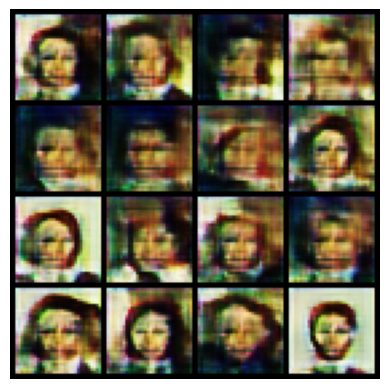

In [24]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("outputs/step3_epoch9.png")
plt.imshow(img)
plt.axis("off")